In [294]:
import numpy as np
import pandas as pd
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import warnings

In [295]:
warnings.filterwarnings("ignore")

## 1. Загрузка данных и аудит

In [296]:
path = r"/Users/antonovsergej/Desktop/megafon_test/test_data.xlsx"

clients = pd.read_excel(path, sheet_name="clients")
tickets = pd.read_excel(path, sheet_name="tickets")
churn = pd.read_excel(path, sheet_name="churn_log")
error_log = pd.read_excel(path, sheet_name="error_log")

In [297]:
clients.head(5)

,client_id,segment,contract_start_date,monthly_revenue
0,C000001,Enterprise,2022/02/05,79941.0
1,C000002,enterprise,2021/02/11,82311.0
2,C000003,ENTERPRISE,2023/08/04,274224.0
3,C000004,enterprise,03-04-2023,93429.0
4,C000005,smb,2023-09-19,294760.0


In [298]:
tickets.head(5)

,ticket_id,client_id,created_at,status,resolution_time_hours,is_first_contact
0,T0000001,C132402,2023-03-04 00:00,Pending,10.703210,1.0
1,T0000002,C001754,2023-09-09 00:00,Open,NaN,1.0
2,T0000003,C053091,2023-02-05 00:00,CLOSED,72.676475,1.0
3,T0000004,C019928,2023-05-30 00:00,Pending,33.357835,1.0
4,T0000005,C108372,2023-02-15 00:00,Open,10.231855,1.0


In [299]:
churn.head(5)

,client_id,churn_date,reason_code
0,C118701,2023-10-21,Other
1,C137094,2023-06-30,Unknown
2,C099431,2023-06-21,Price
3,C132274,2023-09-23,Unknown
4,C035640,2023-08-05,Other


In [300]:
error_log.head(5)

,client_id
0,C000514
1,C000718
2,C000951
3,C001176
4,C001393


In [301]:
print(f"""
clients   : {clients.shape}
tickets   : {tickets.shape}
churn     : {churn.shape}
error_log : {error_log.shape}
""")


clients   : (150000, 4)
tickets   : (60320, 6)
churn     : (2550, 3)
error_log : (80, 1)



In [302]:
# аудит данных 
audit = {
    "clients.segment вариантов написания": clients["segment"].nunique(dropna=True),
    "clients.segment пропусков": int(clients["segment"].isna().sum()),
    "clients.contract_start_date пропусков": int(clients["contract_start_date"].isna().sum()),
    "clients.monthly_revenue пропусков": int(clients["monthly_revenue"].isna().sum()),
    "tickets дублей ticket_id": int(tickets["ticket_id"].duplicated().sum()),
    "tickets отрицательный resolution_time": int((tickets["resolution_time_hours"] < 0).sum()),
    "tickets resolution_time пропусков": int(tickets["resolution_time_hours"].isna().sum()),
    "tickets is_first_contact пропусков": int(tickets["is_first_contact"].isna().sum()),
    "churn сирот (нет в clients)": int((~churn["client_id"].isin(clients["client_id"])).sum()),
    "error_log клиентов на исключение": int(error_log["client_id"].nunique()),
}

In [303]:
for i, j in audit.items():
    print(f'{i}: {j}')

clients.segment вариантов написания: 9
clients.segment пропусков: 40
clients.contract_start_date пропусков: 72
clients.monthly_revenue пропусков: 9
tickets дублей ticket_id: 30320
tickets отрицательный resolution_time: 1727
tickets resolution_time пропусков: 4755
tickets is_first_contact пропусков: 100
churn сирот (нет в clients): 50
error_log клиентов на исключение: 80


In [304]:
# сохраним кол-во строк для будущего сравнения
n_c_before = len(clients)
n_t_before = len(tickets)
n_ch_before = len(churn)

## 2. Очистка данных

In [305]:
# первым делом удаляем невалидные строки 
bad_id = set(error_log["client_id"])

clients = clients[~clients["client_id"].isin(bad_id)].copy()
tickets = tickets[~tickets["client_id"].isin(bad_id)].copy()
churn = churn[~churn["client_id"].isin(bad_id)].copy()

print(f"""
Исключено: {len(bad_id)}
Детальнее:
    clients {n_c_before} -> {len(clients)}
    tickets {n_t_before} -> {len(tickets)}
    churn {n_ch_before} -> {len(churn)}
""")


Исключено: 80
Детальнее:
    clients 150000 -> 149920
    tickets 60320 -> 60282
    churn 2550 -> 2483



In [306]:
# clients нормализация сегмента
#print(set(clients["segment"]))
seg_map = {"smb": "SMB", "enterprise": "Enterprise"}
seg_norm = clients["segment"].astype("string").str.strip().str.lower()
clients["segment"] = seg_norm.map(seg_map)
clients["segment"] = clients["segment"].fillna("Unknown")
print(f"Нормализованный сегмент -> {clients['segment'].unique()}")

Нормализованный сегмент -> ['Enterprise' 'SMB' 'Unknown']


In [307]:
# единый парсер дат
def parser_date(x):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    for fmt in ("%Y/%m/%d", "%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y", "%m/%d/%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue

    return pd.to_datetime(s, errors="coerce", dayfirst=True)

clients["contract_start_date"] = clients["contract_start_date"].apply(parser_date)
tickets["created_at"] = tickets["created_at"].apply(parser_date)
churn["churn_date"] = churn["churn_date"].apply(parser_date)

print(f"""
Даты преобразованы. 
Проверка диапозона дат:
    clients: {clients["contract_start_date"].min()} - {clients["contract_start_date"].max()}
    tickets: {tickets["created_at"].min()} - {tickets["created_at"].max()}
    churn: {churn["churn_date"].min()} - {churn["churn_date"].max()}
""")


Даты преобразованы. 
Проверка диапозона дат:
    clients: 2021-01-01 00:00:00 - 2023-09-28 00:00:00
    tickets: 2023-01-01 00:00:00 - 2024-01-01 00:00:00
    churn: 2017-06-23 00:00:00 - 2023-11-28 00:00:00



In [308]:
# clients импутация revenue
med = clients.groupby("segment")["monthly_revenue"].transform("median")
clients["monthly_revenue"] = clients["monthly_revenue"].fillna(med)
clients["monthly_revenue"] = clients["monthly_revenue"].fillna(clients["monthly_revenue"].median())

In [309]:
# tickets дедупликация
tickets = tickets.drop_duplicates() # удаление "чистых" дублей
tickets["_na"] = tickets.isna().sum(axis=1)
tickets = (tickets.sort_values("_na")
                  .drop_duplicates(subset="ticket_id", keep="first")
                  .drop(columns="_na"))
print(f"""
tickets удалены дубли: {n_t_before} -> {len(tickets)} (уникальных: {tickets['ticket_id'].nunique()})
""")


tickets удалены дубли: 60320 -> 29981 (уникальных: 29981)



In [310]:
# tickets нормализация статусов 
#print(set(tickets["status"]))

tickets["status"] = tickets["status"].astype("string").str.strip().str.title()
print(f"Нормализованный статус -> {tickets["status"].unique()}")

Нормализованный статус -> <StringArray>
['Pending', 'Open', 'Closed']
Length: 3, dtype: string


In [311]:
# отрицательный resolution_time_hours
n_neg = int((tickets["resolution_time_hours"] < 0).sum())
tickets.loc[tickets["resolution_time_hours"] < 0, "resolution_time_hours"] = np.nan

# импутация для таймин-анализа
med_s = tickets.groupby("status")["resolution_time_hours"].transform("median")
tickets["resolution_time_filled"] = tickets["resolution_time_hours"].fillna(med_s)

print(f"resolution_time_hours: {n_neg} отриц. -> NaN. Импутация в отдельную колонку")

resolution_time_hours: 858 отриц. -> NaN. Импутация в отдельную колонку


In [312]:
# удалем "сирот". отток клиента, которого нет в базе - не считается. CR - завышается
n_s = int((~churn['client_id'].isin(clients['client_id'])).sum())

churn = churn[churn["client_id"].isin(clients["client_id"])].copy()
churn = churn.drop_duplicates(subset="client_id", keep="first")
print(f"churn удалено {n_s} сирот, осталось {len(churn)} записей")

churn удалено 50 сирот, осталось 2433 записей


In [313]:
# проверка невозможного оттока 
n_b_before = len(churn)
churn_check = churn.merge(
    clients[["client_id", "contract_start_date"]], on="client_id", how="left"
)
impossible = churn_check["churn_date"] < churn_check["contract_start_date"]
n_impossible = int(impossible.fillna(False).sum())
#print(imopossible)

#удаляем невозможный отток

churn = (churn_check[~impossible.fillna(False)]
         .drop(columns=["contract_start_date"])
         .copy())

print(f"""
churn. было: {n_b_before} -> удалено {n_impossible} -> осталось {len(churn)}
""")


churn. было: 2433 -> удалено 91 -> осталось 2342



In [314]:
# согласуем окно наблюдения с тикетом 
# проблема - тикеты охватывают только 2023 год, а churn - более широкий преиод FCR(2023) нельзя сопоставлять с оттоком других лет
# причина не может предшествовать следствию 
# решение: оставляем отток внутри 23-ого года 

window_start = pd.Timestamp("2023-01-01")
window_end = pd.Timestamp("2023-12-31")

n_a_before = len(churn)
churn = churn[
    (churn["churn_date"] >= window_start) &
    (churn["churn_date"] <= window_end)
].copy()
n_removed = n_a_before - len(churn)

print(f"""
churn. было: {n_a_before} -> удалено {n_removed} -> осталось {len(churn)} 
""")


churn. было: 2342 -> удалено 1 -> осталось 2341 



## Этап 3. Расчет метрик

In [315]:
# FCR
# определение - обращение решено с первого контакта = is_firstt_contact = 1 & status = Closed

tickets["fcr_flag"] = ((tickets["is_first_contact"] == 1) &
                       (tickets["status"] == "Closed")).astype(int)
n_closed = int((tickets["status"] == "Closed").sum())
n_all = len(tickets)
n_fcr = int(tickets["fcr_flag"].sum())

fcr = n_fcr / n_closed
fcr_all = n_fcr / n_all

print(f"""
FCR: 
    Решено с первого контакта: {n_fcr}
    Закртытх тикетов: {n_closed}
    FCR = {fcr:.2%}
""")


FCR: 
    Решено с первого контакта: 9918
    Закртытх тикетов: 19926
    FCR = 49.77%



In [316]:
# Churn Rate
base = clients["client_id"].nunique()
n_churned = churn["client_id"].nunique()
churn_rate = n_churned / base
print(f"""
Churn Rate (согласованное окно 2023):
    База клиентов: {base}
    Ушедших в 2023: {n_churned}
    Churn Rate = {churn_rate:.2%}
""")


Churn Rate (согласованное окно 2023):
    База клиентов: 149920
    Ушедших в 2023: 2341
    Churn Rate = 1.56%



## Этап 4. Гипотеза: коррелирует ли низкий FCR  с оттоком?

In [317]:
# считаем FCR на уровне клиента и сравниваем ушедших vs оставшихся

cl = tickets.groupby("client_id").agg(
    n_tickets=("ticket_id", "count"),
    n_fcr=("fcr_flag", "sum"),
).reset_index()

cl["client_fcr"] = cl["n_fcr"] / cl["n_tickets"]
cl["churned"] = cl["client_id"].isin(set(churn["client_id"])).astype(int)
cl = cl.merge(clients[["client_id", "segment", "monthly_revenue"]], on="client_id", how="left")

fcr_churn = cl.loc[cl["churned"] == 1, "client_fcr"]
fcr_stay =  cl.loc[cl["churned"] == 0, "client_fcr"]

print(f"""
Клиентов с обращениями: {len(cl)} (ушедших {cl['churned'].sum()})
    Средний FCR ушедших: {fcr_churn.mean():.2%}
    Средний FCR оставшиеся: {fcr_stay.mean():.2%}
""")


Клиентов с обращениями: 29981 (ушедших 449)
    Средний FCR ушедших: 34.30%
    Средний FCR оставшиеся: 33.06%



In [318]:
# стат тесты 

# welch t-tets. проверить значимость в средних. почему welch а не student - не предполагается равенство дисперсий в группах - безопаснее
t_stat, t_p = stats.ttest_ind(fcr_churn, fcr_stay, equal_var=False)
# mann-whitney U. проверить одна группа системно выше другой? почем этот тест - непараметрическая альтернатива t-test
# не требущая нормального распределния
u_stat, u_p = stats.mannwhitneyu(fcr_churn, fcr_stay, alternative="two-sided")
# point biserialr. частный случай корреляции Пирсона. Показывает не только связь но и силу связи 
pb_r, pb_p = stats.pointbiserialr(cl["churned"], cl["client_fcr"])

print(f"""
Статистические тесты: 
    Welch t-test:        t = {t_stat:3f}, p = {t_p:.3e}
    Mann-Whitney U:      U = {u_stat:0f}, p = {u_p:.3e}
    Point-biserial corr: r = {pb_r:.3f}, p = {pb_p:.3e}
""")


Статистические тесты: 
    Welch t-test:        t = 0.547043, p = 5.846e-01
    Mann-Whitney U:      U = 6711880.000000, p = 5.806e-01
    Point-biserial corr: r = 0.003, p = 5.806e-01



In [319]:
# примечание! у капждого клиента ровно 1 тикет. FCR бинарный 0-1

n_per = cl["n_tickets"].mean()
print(f"Среднее кол-во обращений на клиента {n_per:.1f}")

cl["fcr_group"] = np.where(cl["client_fcr"] >= 0.5, "Решено с 1-ого контакта", "Не решено с 1-ого контакта")

bucket = cl.groupby("fcr_group").agg(
    clients=("client_id", "count"),
    churned=("churned", "sum")
).reset_index()
bucket["churn_rate"] = bucket["churned"] / bucket["clients"]

print("\nChurn Rate по группам FCR:")
for _, i in bucket.iterrows(): 
    print(f"    {i['fcr_group']:<28}: клиентов {int(i['clients']):>6}, churn {i['churn_rate']:.2%}")

cont = pd.crosstab(cl['fcr_group'], cl['churned'])
chi2, chi_p, _, _ = stats.chi2_contingency(cont)
print(f"    Хи-квадрат: chi2 = {chi2:.2f}, p = {chi_p:.3e}")

verdict = "ПОДТВЕРЖДАЕТСЯ" if (t_p < 0.05 and pb_r < 0) else "НЕ ПОДТВЕРЖДАЕТСЯ"
print(f"\nВывод: гипотеза {verdict}. r = {pb_r:.3f}, все p > 0.05")

Среднее кол-во обращений на клиента 1.0

Churn Rate по группам FCR:
    Не решено с 1-ого контакта  : клиентов  20063, churn 1.47%
    Решено с 1-ого контакта     : клиентов   9918, churn 1.55%
    Хи-квадрат: chi2 = 0.25, p = 6.157e-01

Вывод: гипотеза НЕ ПОДТВЕРЖДАЕТСЯ. r = 0.003, все p > 0.05


## Этап 5. Графики

In [320]:
# цвета мегафон
MF_GREEN   = "#00B140"   # Зелёный основной
MF_GREEN_D = "#007A2F"   # Зелёный тёмный
MF_GREEN_L = "#A4D65E"   # Лайм
MF_PURPLE  = "#6B2FA0"   # Фиолетовый
MF_DARK    = "#1A1A1A"   # Тёмный 

In [321]:
# СR\выручка по сегментам 

seg = clients.copy()
seg["churned"] = seg["client_id"].isin(set(churn["client_id"])).astype(int)
seg_churn = seg.groupby("segment").agg(
    clients=("client_id", "count"),
    churned=("churned", "sum"),
    avg_revenue=("monthly_revenue", "mean"),
).reset_index()
seg_churn["churn_rate"] = seg_churn["churned"] / seg_churn["clients"]

print("CR и выручка по сегментам")
for _, r in seg_churn.iterrows():
    print(f"   {r['segment']:<11}: клиентов {int(r['clients']):>6}, сhurn {r['churn_rate']:.2%}, avg revenue {r['avg_revenue']:,.0f}")


lost_rev = seg.loc[seg["churned"] == 1, "monthly_revenue"].sum()
total_rev = seg["monthly_revenue"].sum()
print(f"\nУпущенная выручка: {lost_rev:,.0f} р. ({lost_rev / total_rev:.1%} от общей)")

CR и выручка по сегментам
   Enterprise : клиентов  66465, сhurn 1.56%, avg revenue 254,987
   SMB        : клиентов  83416, сhurn 1.56%, avg revenue 254,721
   Unknown    : клиентов     39, сhurn 7.69%, avg revenue 269,552

Упущенная выручка: 602,631,116 р. (1.6% от общей)


In [322]:
# функция единообразной стилистики оформления графиков
def mf_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=14, fontweight="bold", color=MF_DARK, pad=12)
    ax.set_xlabel(xlabel, fontsize=11, color=MF_DARK)
    ax.set_ylabel(ylabel, fontsize=11, color=MF_DARK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=MF_DARK, labelsize=10)
    ax.yaxis.grid(True, color="#EBEBEB", linewidth=0.8)
    ax.set_axisbelow(True)

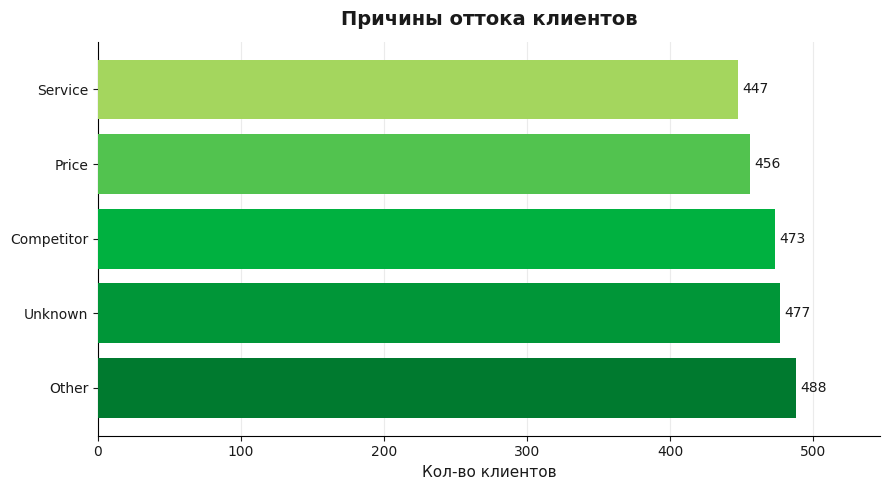

In [323]:
# причина оттока
rc = churn["reason_code"].value_counts()

n = len(rc)
cmap = mcolors.LinearSegmentedColormap.from_list("mf", [MF_GREEN_D, MF_GREEN, MF_GREEN_L], N=n)
bar_colors = [mcolors.to_hex(cmap(i / (n-1))) for i in range(n)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rc.index, rc.values, color=bar_colors_4, zorder=3)
for bar, val in zip(bars, rc.values):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
           str(val), va="center", fontsize=10, color=MF_DARK)
mf_ax(ax, "Причины оттока клиентов", xlabel="Кол-во клиентов")
ax.xaxis.grid(True, color="#EBEBEB", linewidth=0.8)
ax.yaxis.grid(False)
ax.set_xlim(0, rc.max() * 1.12)
plt.tight_layout()
plt.savefig("charts/Причины оттока.png")
plt.show()

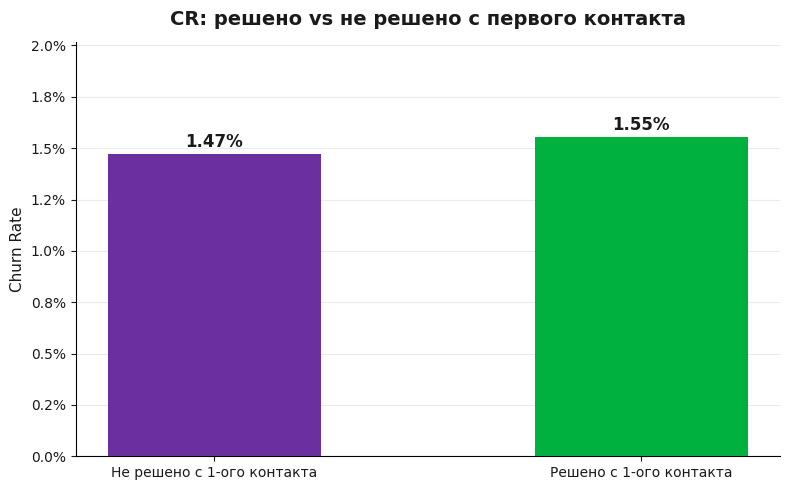

In [324]:
# СR plot
fcr_color_map = {"Не решено с 1-ого контакта": MF_PURPLE,
                 "Решено с 1-ого контакта": MF_GREEN}
bar_colors_1 = [fcr_color_map[b] for b in bucket["fcr_group"]]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(bucket["fcr_group"], bucket["churn_rate"],
              color=bar_colors_1, width=0.5, zorder=3)
for bar, (_, r) in zip(bars, bucket.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00015,
            f"{r['churn_rate']:.2%}", ha="center", va="bottom",
           fontsize=12, fontweight="bold", color=MF_DARK)

mf_ax(ax, "СR: решено vs не решено с первого контакта", ylabel="Churn Rate")
ax.set_ylim(0, bucket["churn_rate"].max() * 1.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.savefig("charts/СR решено vs не решено с первого контакта.png")
plt.show()

In [325]:
fcr_seg_base = tickets.merge(clients[["client_id", "segment"]], on="client_id", how="left")

seg_fcr = fcr_seg_base.groupby("segment").agg(
    closed=("status", lambda s: (s == "Closed").sum()),
    fcr_solved=("fcr_flag", "sum"),
).reset_index()
seg_fcr["fcr_rate"] = seg_fcr["fcr_solved"] / seg_fcr["closed"]
seg_fcr = seg_fcr.sort_values("fcr_rate", ascending=True)

seg_fcr

,segment,closed,fcr_solved,fcr_rate
1,SMB,10992,5381,0.489538
2,Unknown,4,2,0.500000
0,Enterprise,8930,4535,0.507839


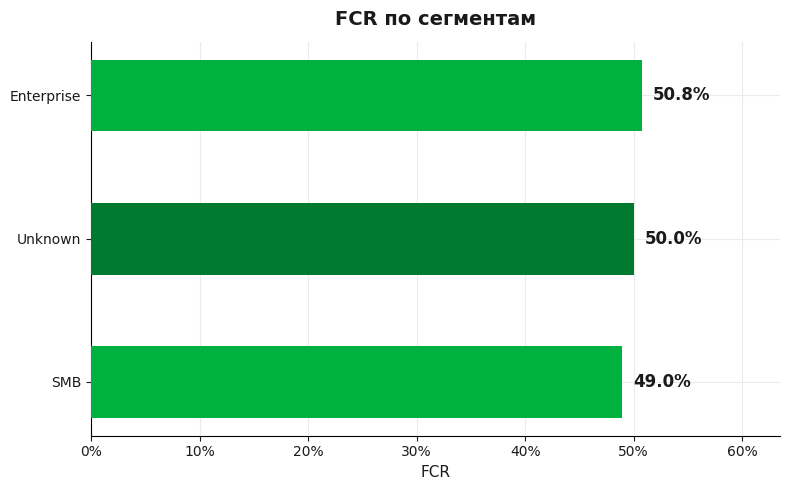

In [326]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(seg_fcr["segment"], seg_fcr["fcr_rate"],
                color=[MF_GREEN, MF_GREEN_D], height=0.5, zorder=3)

for bar, val in zip(bars, seg_fcr["fcr_rate"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.1%}", va="center", fontsize=12, fontweight="bold", color=MF_DARK)

mf_ax(ax, "FCR по сегментам", xlabel="FCR")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlim(0, seg_fcr["fcr_rate"].max() * 1.25)
ax.xaxis.grid(True, color="#EBEBEB", linewidth=0.8)

plt.tight_layout()
plt.savefig("charts/FCR по сегментам.png")
plt.show()

## ДОП
FCR не объяснил отток. Ищем факторы, которые помогут его объяснить. Предлагаю три варианта:
  - Revenue-профиль по ушедшим (кого теряем)
  - Time to churn и Когорты (когда теряем)
  - Качество поддержки: время решения, статус тикета, лаг до оттока

## Revenue-профиль

In [327]:
seg1 = clients.copy()
seg1["churned"] = seg1["client_id"].isin(set(churn["client_id"])).astype(int)

# децель по выручке. Децель делит базу на 10 равных частей
seg1["rev_decile"] = pd.qcut(seg1["monthly_revenue"], q=10, labels=False) + 1
decile = seg1.groupby("rev_decile").agg(
    clients = ("client_id", "count"),
    churned = ("churned", "sum"),
    avg_rev = ("monthly_revenue", "mean"),
).reset_index()
decile["churn_rate"] = decile["churned"] / decile["clients"]
decile["rev_k"] = decile["avg_rev"] / 1000

output_df = decile[['rev_decile', 'avg_rev', 'churn_rate']].copy()
output_df['rev_decile'] = output_df['rev_decile'].astype(int)
output_df.style.format({
    'avg_rev': '{:,.0f}',
    'churn_rate': '{:.2%}'
}).hide(axis='index')  

rev_decile,avg_rev,churn_rate
1,"34,535",1.45%
2,"83,607",1.66%
3,"132,404",1.50%
4,"181,217",1.53%
5,"230,232",1.63%
6,"278,951",1.61%
7,"328,230",1.39%
8,"377,257",1.53%
9,"426,422",1.65%
10,"475,577",1.65%


In [328]:
# сравнение медиан 
med_ch = seg1.loc[seg1["churned"]==1, "monthly_revenue"].median()
med_ret = seg1.loc[seg1["churned"]==0, "monthly_revenue"].median()
t_rev, p_rev = stats.mannwhitneyu(
    seg1.loc[seg1["churned"]==1, "monthly_revenue"],
    seg1.loc[seg1["churned"]==0, "monthly_revenue"],
    alternative="two-sided"
)
print(f"""
Медиана выручки:
    - ушедшие {med_ch:,.0f}
    - оставшиеся {med_ret:,.0f}
Mann-Whitneyu p = {p_rev:.3e} ({'значимо' if p_rev < 0.05 else 'не значимо'})
""")


Медиана выручки:
    - ушедшие 255,432
    - оставшиеся 254,459
Mann-Whitneyu p = 3.739e-01 (не значимо)



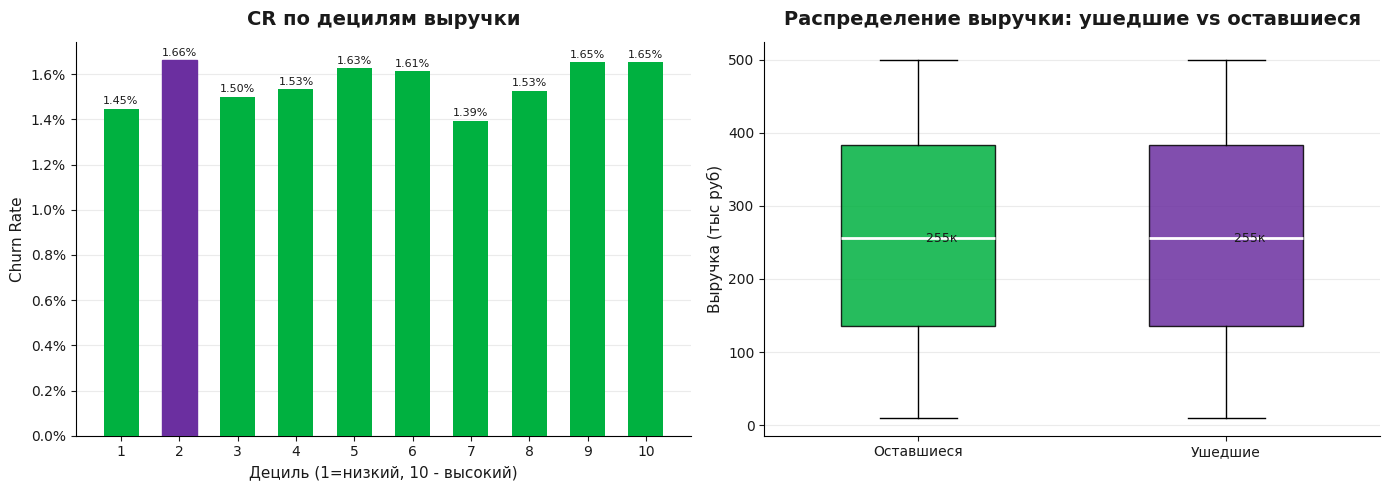

In [329]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# левый 
ax = axes[0]
colord_d = [MF_PURPLE if r == decile["churn_rate"].idxmax() + 1
            else MF_GREEN for r in decile["rev_decile"]]
bars = ax.bar(decile["rev_decile"].astype(str), decile["churn_rate"],
              color=MF_GREEN, width=0.6, zorder=3)
# выделить максимум
max_idx = decile["churn_rate"].idxmax()
bars[max_idx].set_color(MF_PURPLE)
for bar, (_, r) in zip(bars, decile.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
           f"{r['churn_rate']:.2%}", ha="center", va="bottom", fontsize=8, color=MF_DARK)
mf_ax(ax, "CR по децилям выручки", xlabel="Дециль (1=низкий, 10 - высокий)", ylabel="Churn Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))

#правый 
ax2 = axes[1]
data_box = [seg1.loc[seg1["churned"]==1, "monthly_revenue"] / 1000,
            seg1.loc[seg1["churned"]==1, "monthly_revenue"] / 1000]
bp = ax2.boxplot(data_box, patch_artist=True, widths=0.5,
                 medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], [MF_GREEN, MF_PURPLE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax2.set_xticklabels(["Оставшиеся", "Ушедшие"])
ax2.text(1, data_box[0].median(), f"  {data_box[0].median():.0f}к", va="center", fontsize=9, color=MF_DARK)
ax2.text(2, data_box[1].median(), f"  {data_box[1].median():.0f}к", va="center", fontsize=9, color=MF_DARK)
mf_ax(ax2, "Распределение выручки: ушедшие vs оставшиеся", ylabel="Выручка (тыс руб)")

plt.tight_layout()
plt.savefig("charts/revenue профиль.png")
plt.show()

## Time to churn и Когорты

In [330]:
# T to C 
churn_t = churn.merge(clients[["client_id", "contract_start_date"]], on="client_id", how="left")
churn_t["days_to_churn"] = (churn_t["churn_date"] - churn_t["contract_start_date"]).dt.days
churn_t = churn_t[churn_t["days_to_churn"] >= 0]

print("Time to churn")
print(churn_t['days_to_churn'].describe().map(lambda x: f"{x:.1f}").to_string())

# ранний отток <90 
early = (churn_t["days_to_churn"] < 90).sum()
print(f"\nРанний отток (<90 д.): {early} клиенток ({early / len(churn_t):.1%})")

Time to churn
count    2337.0
mean      487.4
std       281.8
min         1.0
25%       245.0
50%       480.0
75%       728.0
max      1041.0

Ранний отток (<90 д.): 209 клиенток (8.9%)


In [331]:
# когортный анализ
clients_c = clients.copy()
clients_c["churned"] = clients_c["client_id"].isin(set(churn["client_id"])).astype(int)
clients_c["cohort"] = clients_c["contract_start_date"].dt.to_period("Q").astype(str)

cohort = (clients_c.groupby("cohort")
          .agg(clients=("client_id", "count"), churned=("churned", "sum"))
          .reset_index())
cohort["churn_rate"] = cohort["churned"] / cohort["clients"]  
cohort = cohort[cohort["clients"] >= 50] # когорты с достаточной выборкой
cohort = cohort[cohort["cohort"] != "NaT"].copy()

cohort

,cohort,clients,churned,churn_rate
0,2021Q1,13412,212,0.015807
1,2021Q2,13604,224,0.016466
2,2021Q3,13757,213,0.015483
3,2021Q4,13862,221,0.015943
4,2022Q1,13567,230,0.016953
5,2022Q2,13543,224,0.016540
6,2022Q3,13808,219,0.015860
7,2022Q4,13551,219,0.016161
8,2023Q1,13435,218,0.016226
9,2023Q2,13854,214,0.015447


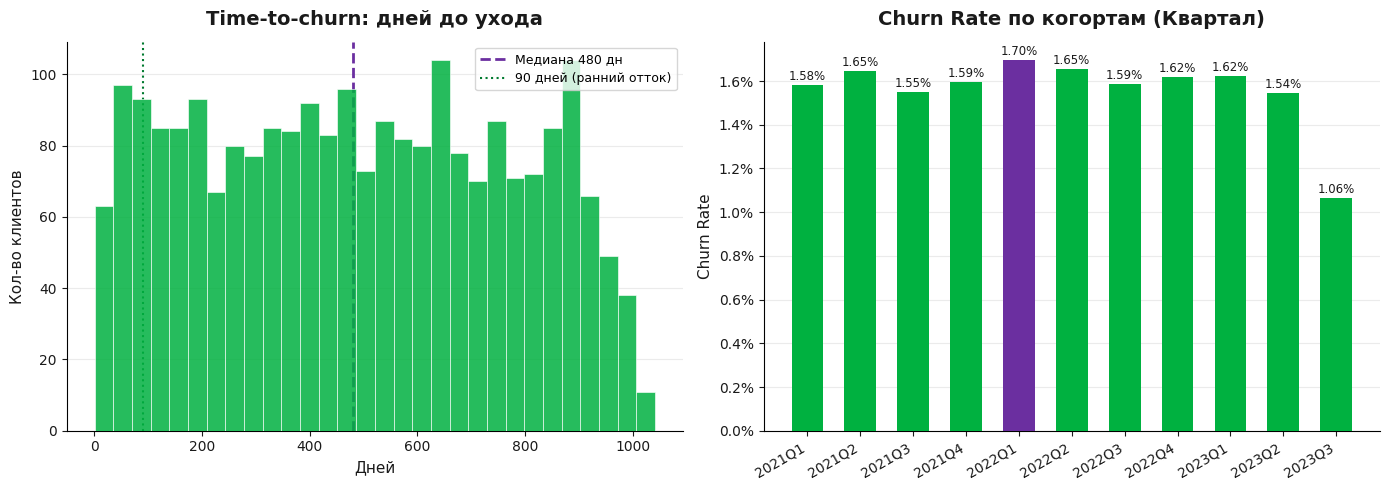

In [332]:
# графики 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# леевый 
ax = axes[0]
ax.hist(churn_t["days_to_churn"], bins=30, color=MF_GREEN, alpha=0.85,
        edgecolor="white", linewidth=0.5, zorder=3)
ax.axvline(churn_t["days_to_churn"].median(), color=MF_PURPLE, 
           linewidth=2, linestyle="--", label=f"Медиана {churn_t['days_to_churn'].median():.0f} дн")
ax.axvline(90, color=MF_GREEN_D, linewidth=1.5, linestyle=":",
          label="90 дней (ранний отток)")
mf_ax(ax, "Time-to-churn: дней до ухода", xlabel="Дней", ylabel="Кол-во клиентов")
ax.legend(fontsize=9)

#правый
ax2 = axes[1]
max_c = cohort["churn_rate"].idxmax()
bar_colors = [MF_PURPLE if i == max_c else MF_GREEN for i in cohort.index]
bars = ax2.bar(cohort["cohort"], cohort["churn_rate"],
               color=bar_colors, width=0.6, zorder=3)
for bar, (_, r) in zip(bars, cohort.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
           f"{r['churn_rate']:.2%}", ha="center", va="bottom", fontsize=8.5, color=MF_DARK)
mf_ax(ax2, "Сhurn Rate по когортам (Квартал)", ylabel="Churn Rate")
ax2.set_xticklabels(cohort["cohort"], rotation=30, ha="right")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))

plt.tight_layout()
plt.savefig("charts/Time-to-churn и Когорты.png")
plt.show()

## Качество поддержки

In [333]:
churned_ids = set(churn["client_id"])
tk_ch = tickets[tickets["client_id"].isin(churned_ids)].copy()
tk_ret = tickets[~tickets["client_id"].isin(churned_ids)].copy()

In [334]:
# время решения
r_ch = tk_ch["resolution_time_filled"].dropna()
r_ret = tk_ret["resolution_time_filled"].dropna()
t_rt, p_rt = stats.mannwhitneyu(r_ch, r_ret, alternative="two-sided")
print(f"""
Время решения:
    Ушедшие: медиана {r_ch.median():.1f} ч, среднее {r_ch.mean():.1f} 
    Оставшиеся: медиана {r_ret.median():.1f} ч, среднее {r_ret.mean():.1f}
    Mann-Whitney p = {p_rt:.3e} ({'значимо' if p_rt < 0.05 else 'не значимо'}) """)


Время решения:
    Ушедшие: медиана 50.2 ч, среднее 50.0 
    Оставшиеся: медиана 50.2 ч, среднее 50.1
    Mann-Whitney p = 9.975e-01 (не значимо) 


In [335]:
# статус тикета
st_ch = tk_ch["status"].value_counts(normalize=True).rename("Ушедшие")
st_ret = tk_ret["status"].value_counts(normalize=True).rename("Оставшиеся")
st_df = pd.concat([st_ch, st_ret], axis=1).fillna(0)
print("Распределение статусов тикетов:")
print(st_df.applymap(lambda x: f"{x:.1%}").to_string())

Распределение статусов тикетов:
        Ушедшие Оставшиеся
status                    
Closed    65.7%      66.5%
Pending   18.7%      16.7%
Open      15.6%      16.8%


In [336]:
# хи-квадрат
cont_st = pd.crosstab(tickets["status"],
                      tickets["client_id"].isin(churned_ids).map({True:"shurned", False:"retained"}))
chi_st, p_chi_st, _, _ = stats.chi2_contingency(cont_st)
print(f"Хи-Квадрат p = {chi_st:.3e} ({'значимо' if chi_st < 0.05 else 'не значимо'}) ")

Хи-Квадрат p = 1.472e+00 (не значимо) 


In [337]:
# лаг тикета - отток
tk_dates = tickets[["client_id", "created_at"]].copy()
tk_dates["created_at"] = pd.to_datetime(tk_dates["created_at"], errors="coerce")
lag = (churn.merge(tk_dates, on="client_id", how="left")
            .assign(lag_days=lambda x: (x["churn_date"] - x["created_at"]).dt.days))
lag = lag[lag["lag_days"].between(0, 365)]
print("Лак тикета -> отток")
lag["lag_days"].describe()

Лак тикета -> отток


count    311.000000
mean     110.739550
std       75.173689
min        0.000000
25%       48.500000
50%       97.000000
75%      162.500000
max      317.000000
Name: lag_days, dtype: float64

In [338]:
early_lag = (lag["lag_days"] < 30).sum()
print(f"Ушли в течение 30 дней после обращений: {early_lag} ({early_lag / len(lag):.1%})")

Ушли в течение 30 дней после обращений: 51 (16.4%)


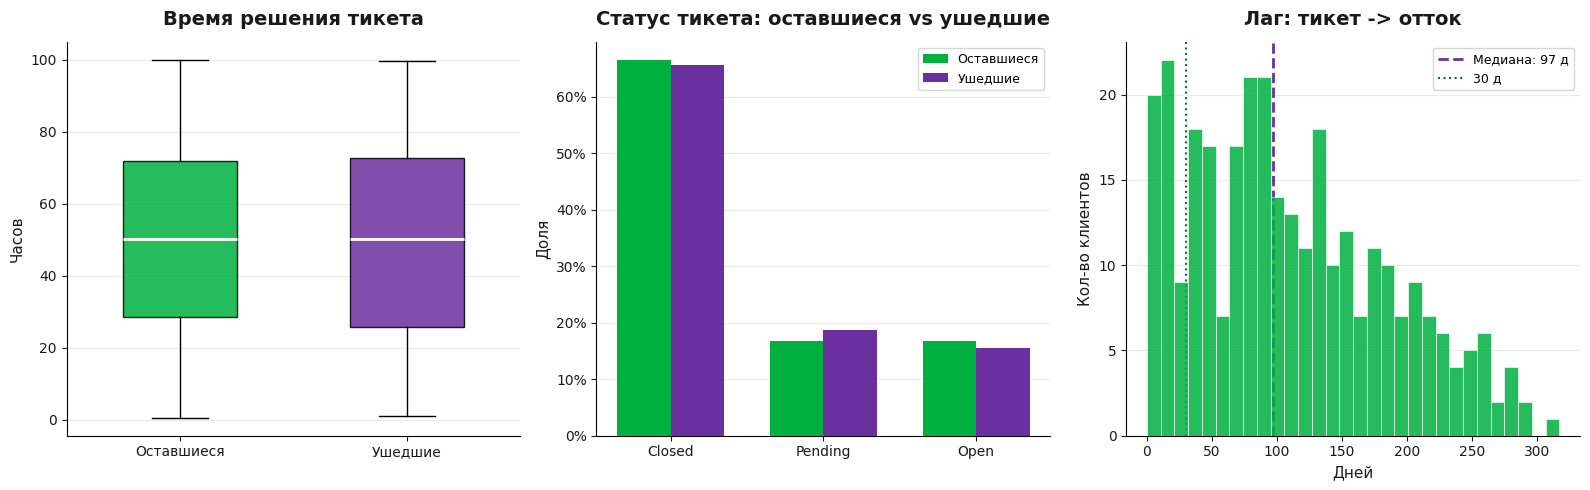

In [339]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# левый 
ax = axes[0]
bp = ax.boxplot([r_ret, r_ch], patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], [MF_GREEN, MF_PURPLE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.set_xticklabels(["Оставшиеся", "Ушедшие"])
mf_ax(ax, "Время решения тикета", ylabel="Часов")

# центр
ax2 = axes[1]
x = range(len(st_df))
w = 0.35
b1 = ax2.bar([i - w/2 for i in x], st_df["Оставшиеся"], width=w,
             color=MF_GREEN, label="Оставшиеся", zorder=3)
b2 = ax2.bar([i + w/2 for i in x], st_df["Ушедшие"], width=w,
             color=MF_PURPLE, label="Ушедшие", zorder=3)
ax2.set_xticks(list(x))
ax2.set_xticklabels(st_df.index)
ax2.legend(fontsize=9)
mf_ax(ax2, "Статус тикета: оставшиеся vs ушедшие", ylabel="Доля")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

#правая
ax3 = axes[2]
ax3.hist(lag["lag_days"], bins=30, color=MF_GREEN, alpha=0.85,
         edgecolor="white", linewidth=0.5, zorder=3)
ax3.axvline(lag["lag_days"].median(), color=MF_PURPLE, linewidth=2,
            linestyle="--", label=f"Медиана: {lag['lag_days'].median():.0f} д")
ax3.axvline(30, color=MF_GREEN_D, linewidth=1.5,
            linestyle=":", label="30 д")
mf_ax(ax3, "Лаг: тикет -> отток", xlabel="Дней", ylabel="Кол-во клиентов")
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig("charts/Качество поддержки")
plt.show()